In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
# Read in the processed dataset
file_path = '../data/processed/processed_data_pre_model.csv'
df = pd.read_csv(file_path)

C:\Users\sbout\AppData\Local\Temp\ipykernel_25932\955667600.py:3: DtypeWarning: Columns (46,48,75,88) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [8]:
# Remove month over month and year over year data.
# Identify features that contain '_mm' or '_yy' and remove them
cols_to_remove = [
    col for col in df.columns 
    if ('_mm' in col or '_yy' in col) and col != 'month_date_yyyymm'
]
df_reduced = df.drop(columns=cols_to_remove)
print(f"Original feature count: {df.shape[1]}")
print(f"Reduced feature count: {df_reduced.shape[1]}")
print(f"Removed features: {cols_to_remove}")

Original feature count: 90
Reduced feature count: 52
Removed features: ['median_listing_price_mm_x', 'median_listing_price_yy_x', 'active_listing_count_mm', 'active_listing_count_yy', 'median_days_on_market_mm_x', 'median_days_on_market_yy_x', 'new_listing_count_mm', 'new_listing_count_yy', 'price_increased_count_mm', 'price_increased_count_yy', 'price_increased_share_mm', 'price_increased_share_yy', 'price_reduced_count_mm', 'price_reduced_count_yy', 'price_reduced_share_mm', 'price_reduced_share_yy', 'pending_listing_count_mm', 'pending_listing_count_yy', 'median_listing_price_per_square_foot_mm', 'median_listing_price_per_square_foot_yy', 'median_square_feet_mm', 'median_square_feet_yy', 'average_listing_price_mm', 'average_listing_price_yy', 'total_listing_count_mm', 'total_listing_count_yy', 'pending_ratio_mm', 'pending_ratio_yy', 'hotness_rank_mm', 'hotness_rank_yy', 'median_days_on_market_mm_y', 'median_dom_mm_day', 'median_days_on_market_yy_y', 'median_dom_yy_day', 'page_view_c

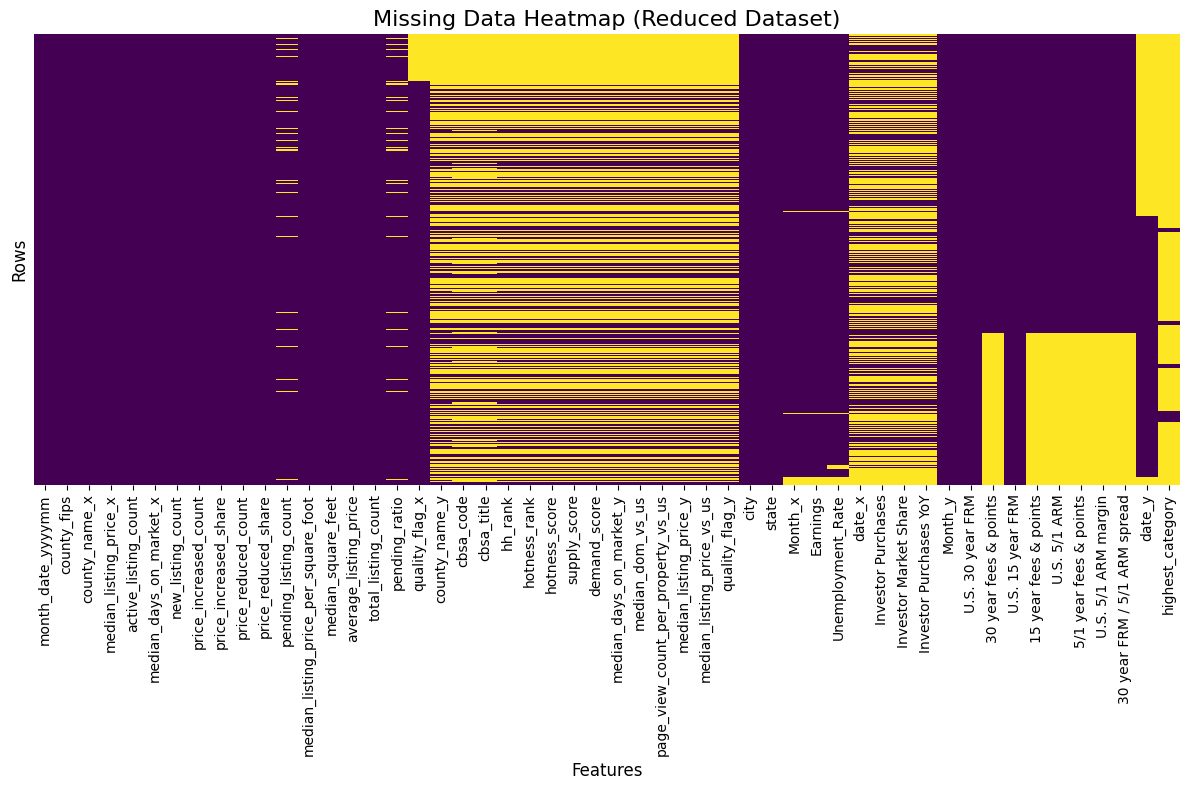

In [9]:
# Create a heatmap showing the missing data of the reduced dataset
plt.figure(figsize=(12, 8))
# df_reduced.isnull() creates a boolean mask where True indicates missing values
sns.heatmap(df_reduced.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Data Heatmap (Reduced Dataset)', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Rows', fontsize=12)
plt.tight_layout()
plt.show()

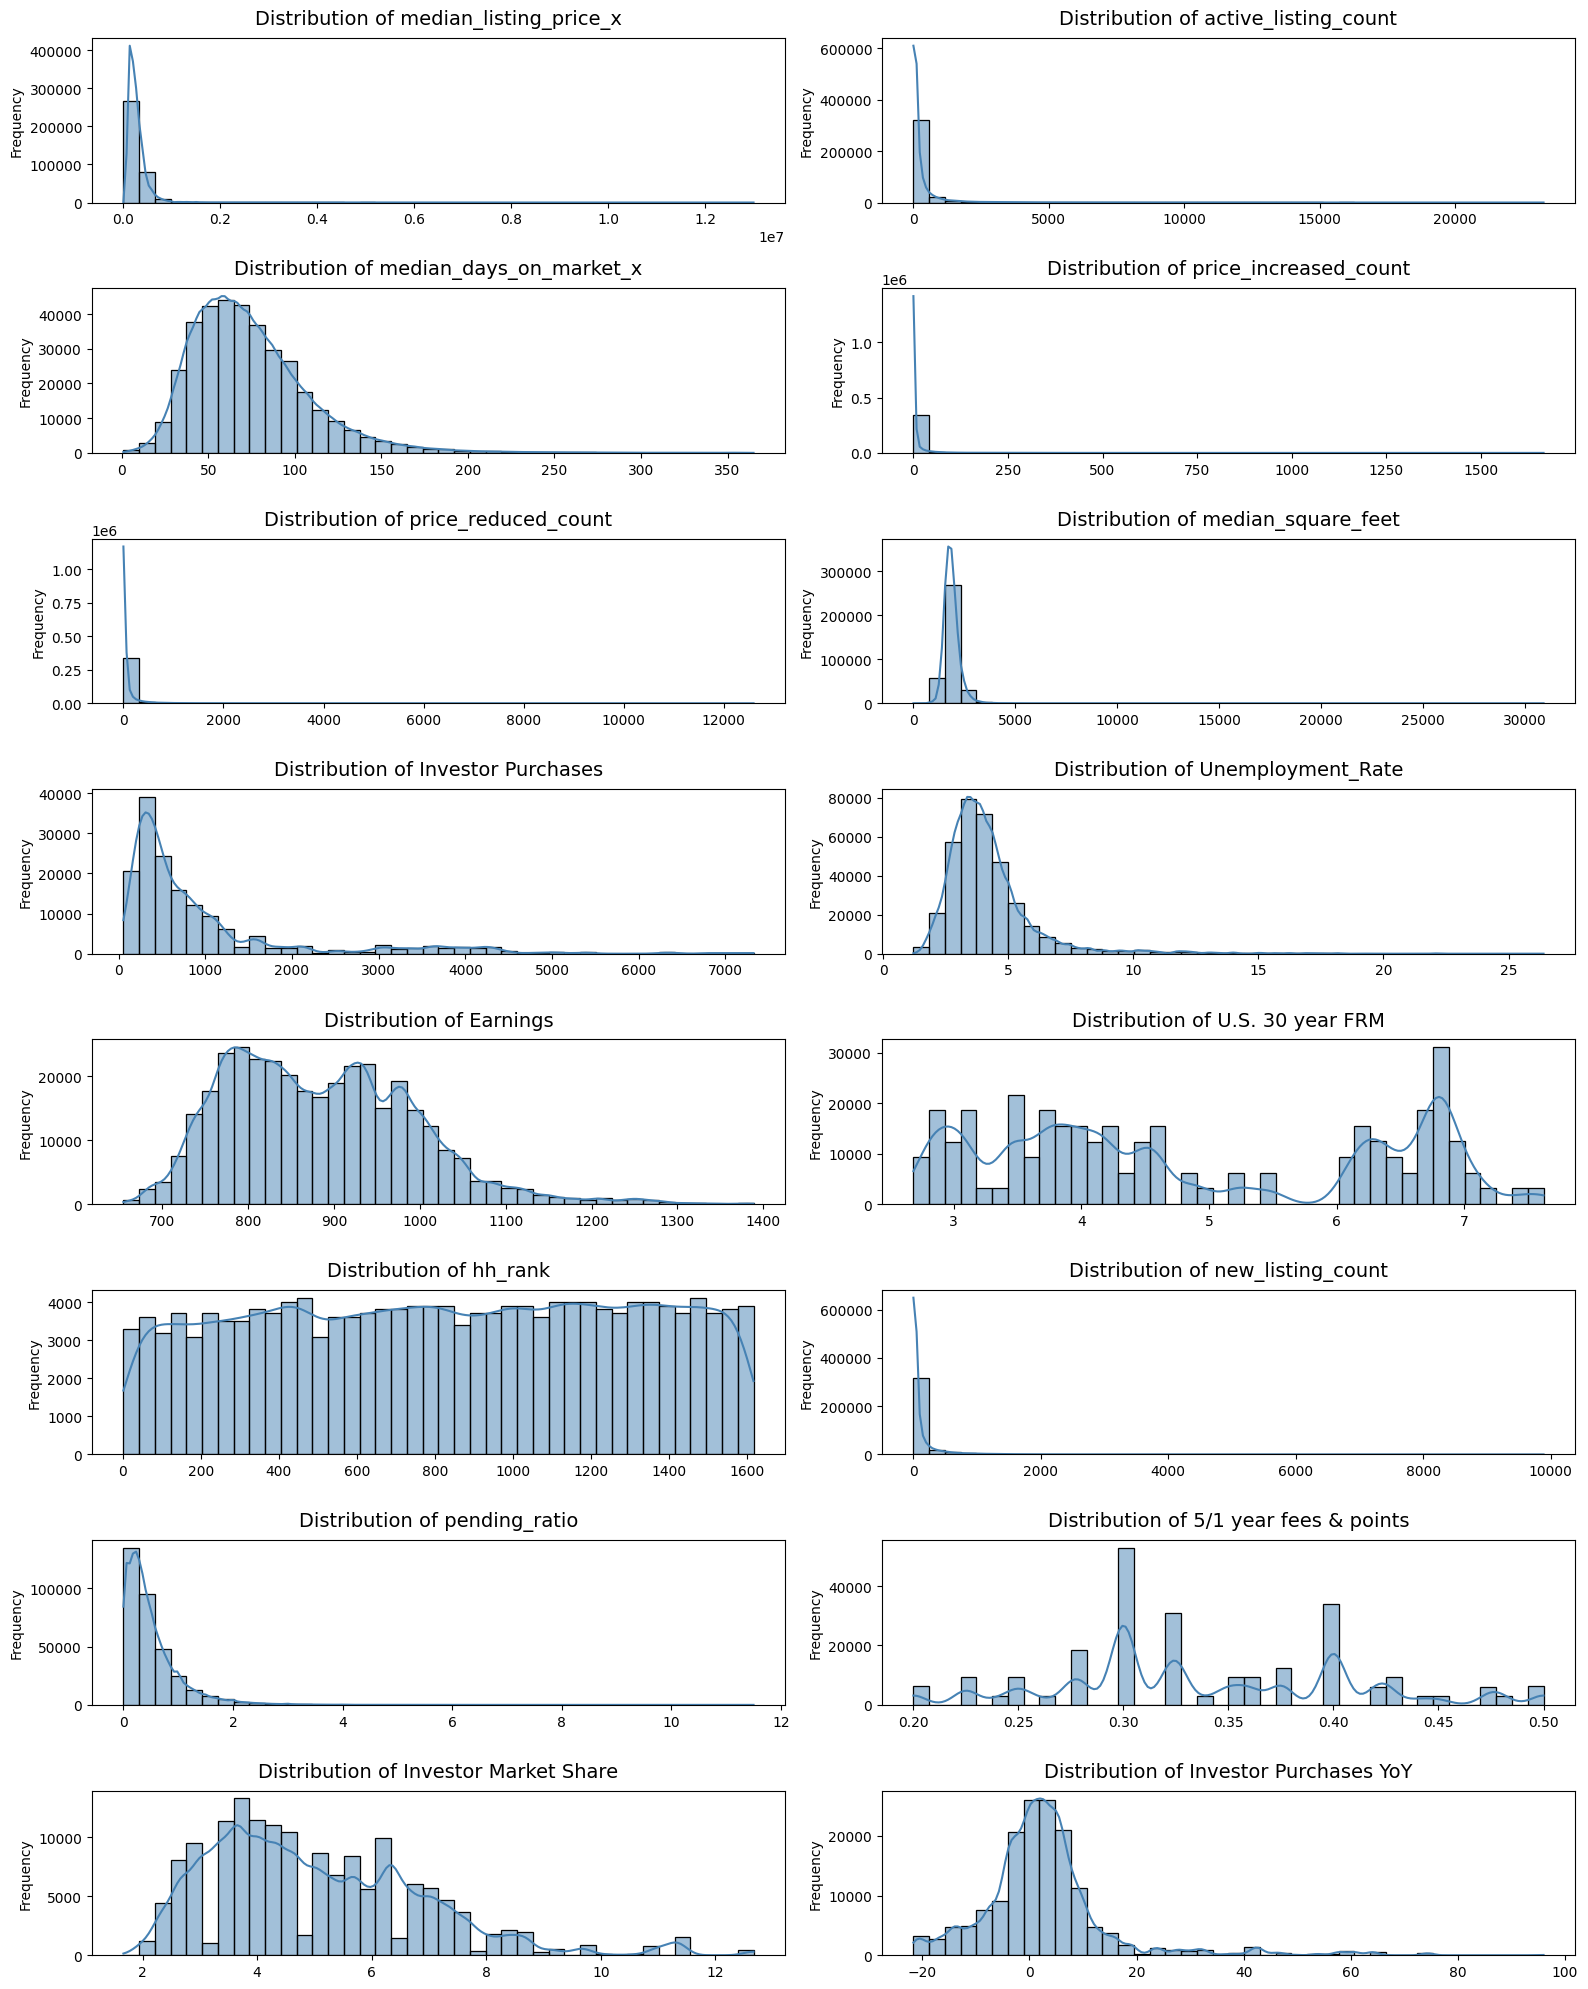

In [32]:
# plot distribution histograms for selected features
columns_to_plot = [
    'median_listing_price_x', 
    'active_listing_count', 
    'median_days_on_market_x', 
    'price_increased_count', 
    'price_reduced_count', 
    'median_square_feet',  
    'Investor Purchases', 
    'Unemployment_Rate', 
    'Earnings', 
    'U.S. 30 year FRM',
    'hh_rank',
    'new_listing_count',
    'pending_ratio',
    '5/1 year fees & points',
    'Investor Market Share',
    'Investor Purchases YoY'
]

# Create a 5x2 grid of subplots
fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(16, 20))

# Flatten the 5x2 grid into a 1D array for easy iteration
axes = axes.flatten()

# Loop through the columns and axes to plot
for i, col in enumerate(columns_to_plot):
    # Just in case there's a slight mismatch in column names, verify it exists
    if col in df_reduced.columns:
        # Plot histogram with a KDE (Kernel Density Estimate) curve
        sns.histplot(data=df_reduced, x=col, kde=True, ax=axes[i], bins=40, color='steelblue')
        axes[i].set_title(f'Distribution of {col}', fontsize=14, pad=10)
        axes[i].set_xlabel('')  # Keep x-axis label clean
        axes[i].set_ylabel('Frequency')
    else:
        # Hide the subplot if the column is missing and print a warning
        axes[i].set_visible(False)
        print(f"Warning: Column '{col}' was not found in df_reduced.")

# Automatically adjust padding so titles and axes don't overlap
plt.tight_layout()
plt.show()


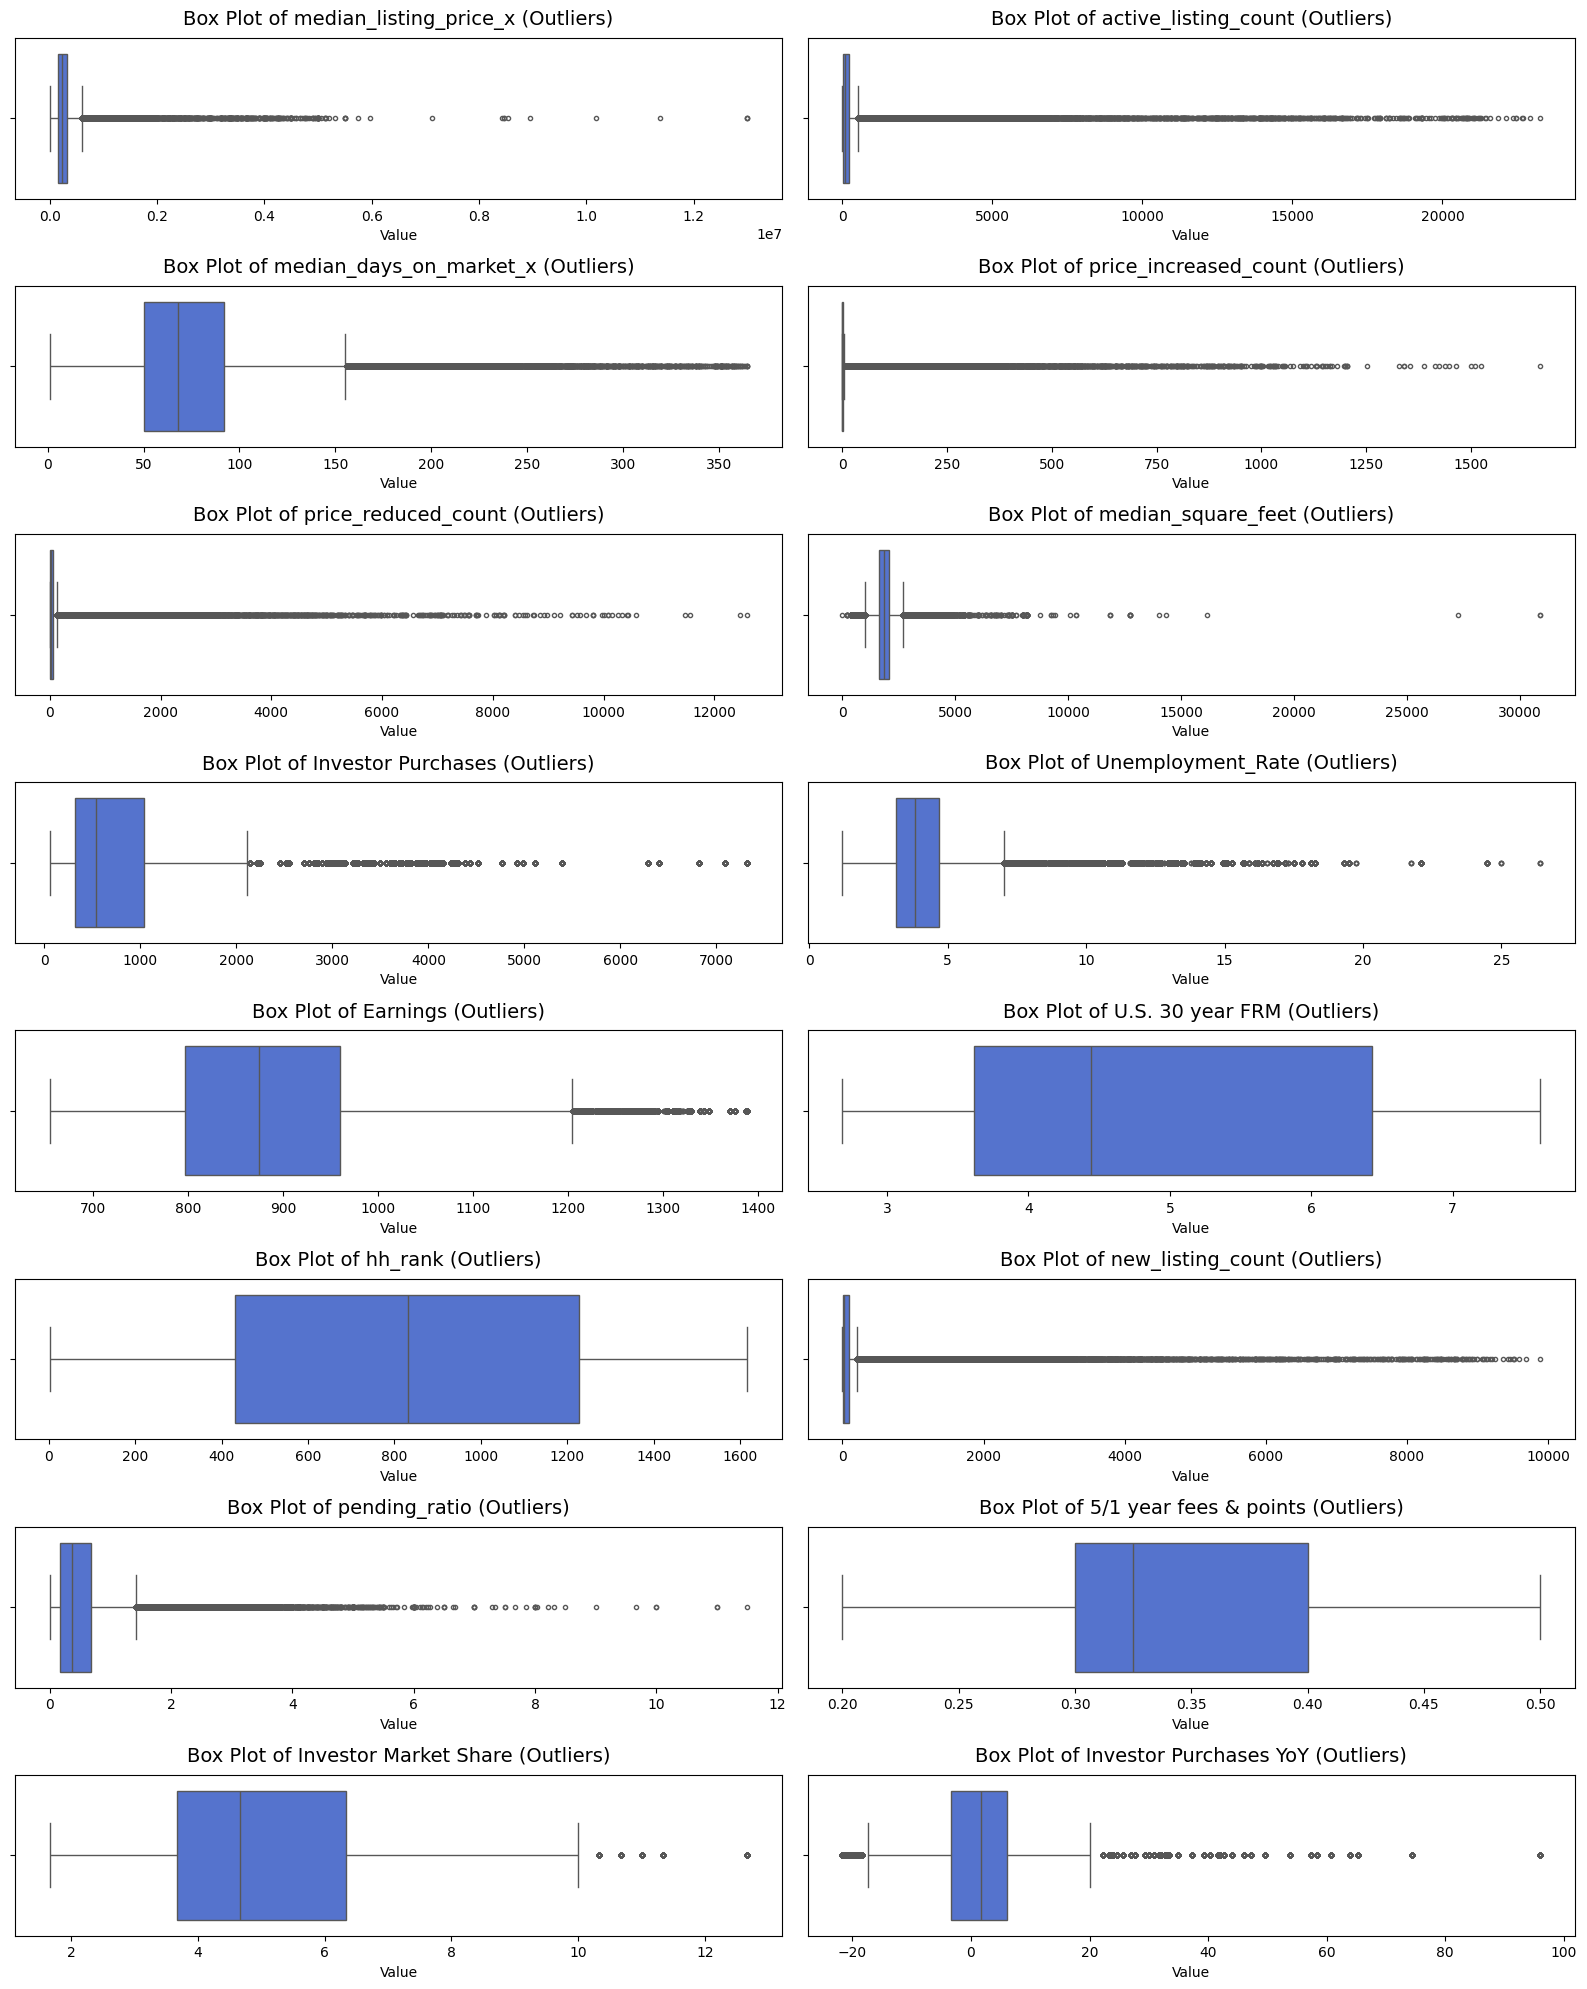

In [33]:
# Set up the matplotlib figure (5 rows x 2 columns)
fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(16, 20))

# Flatten the axes array for an easy loop
axes = axes.flatten()

# Loop over columns
for i, col in enumerate(columns_to_plot):
    if col in df_reduced.columns:
        # Plot the box plot horizontally
        sns.boxplot(data=df_reduced, x=col, ax=axes[i], color='royalblue', fliersize=3)
        axes[i].set_title(f'Box Plot of {col} (Outliers)', fontsize=14, pad=10)
        axes[i].set_xlabel('Value')
    else:
        # Hide the subplot if a column wasn't found
        axes[i].set_visible(False)

# Adjust the layout to keep it looking clean
plt.tight_layout()
plt.show()


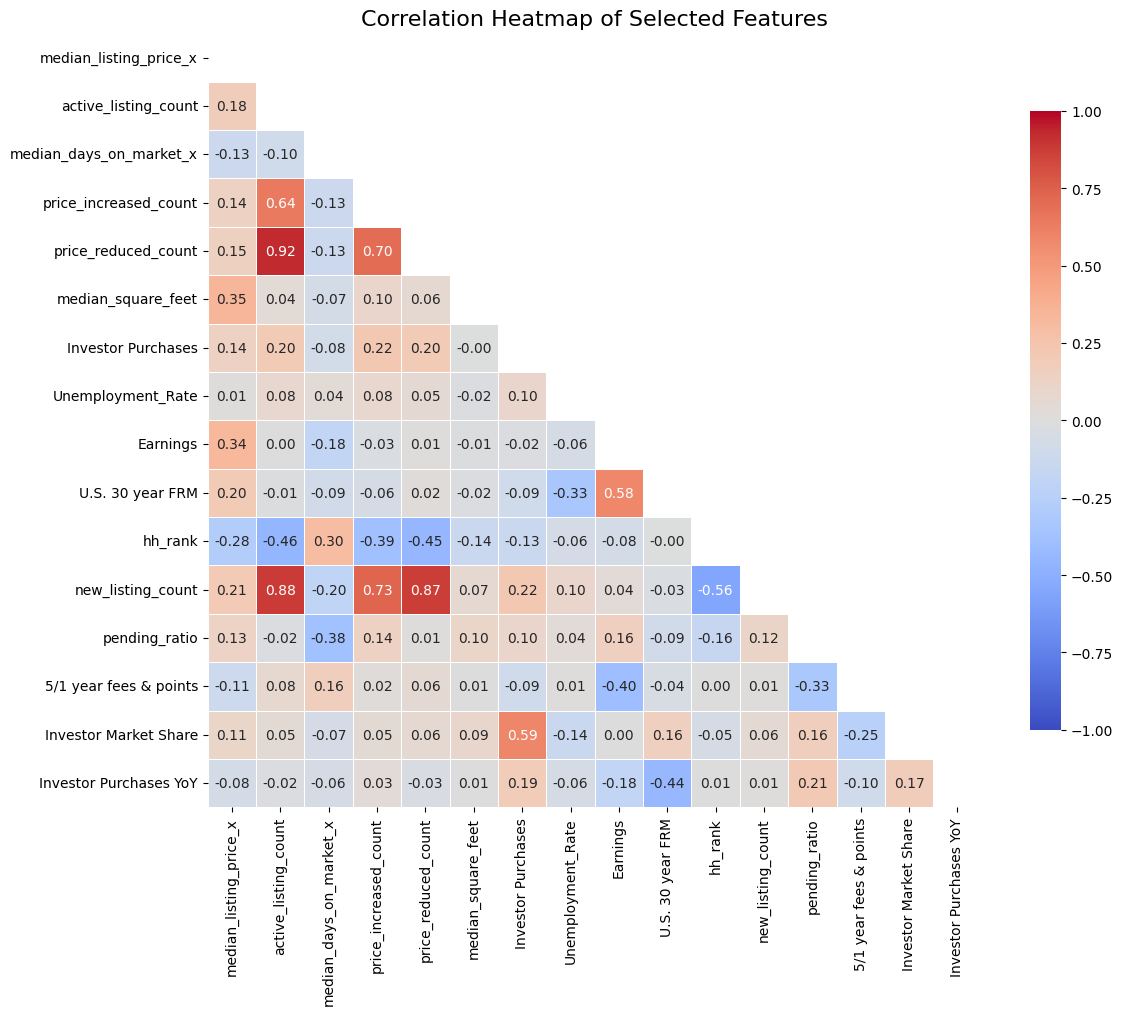

In [34]:
import numpy as np

# Create a figure for the correlation heatmap
plt.figure(figsize=(12, 10))

# Calculate the correlation matrix for selected features
corr_matrix = df_reduced[columns_to_plot].corr()

# Create a mask to hide the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot the heatmap
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap of Selected Features', fontsize=16)
plt.tight_layout()
plt.show()


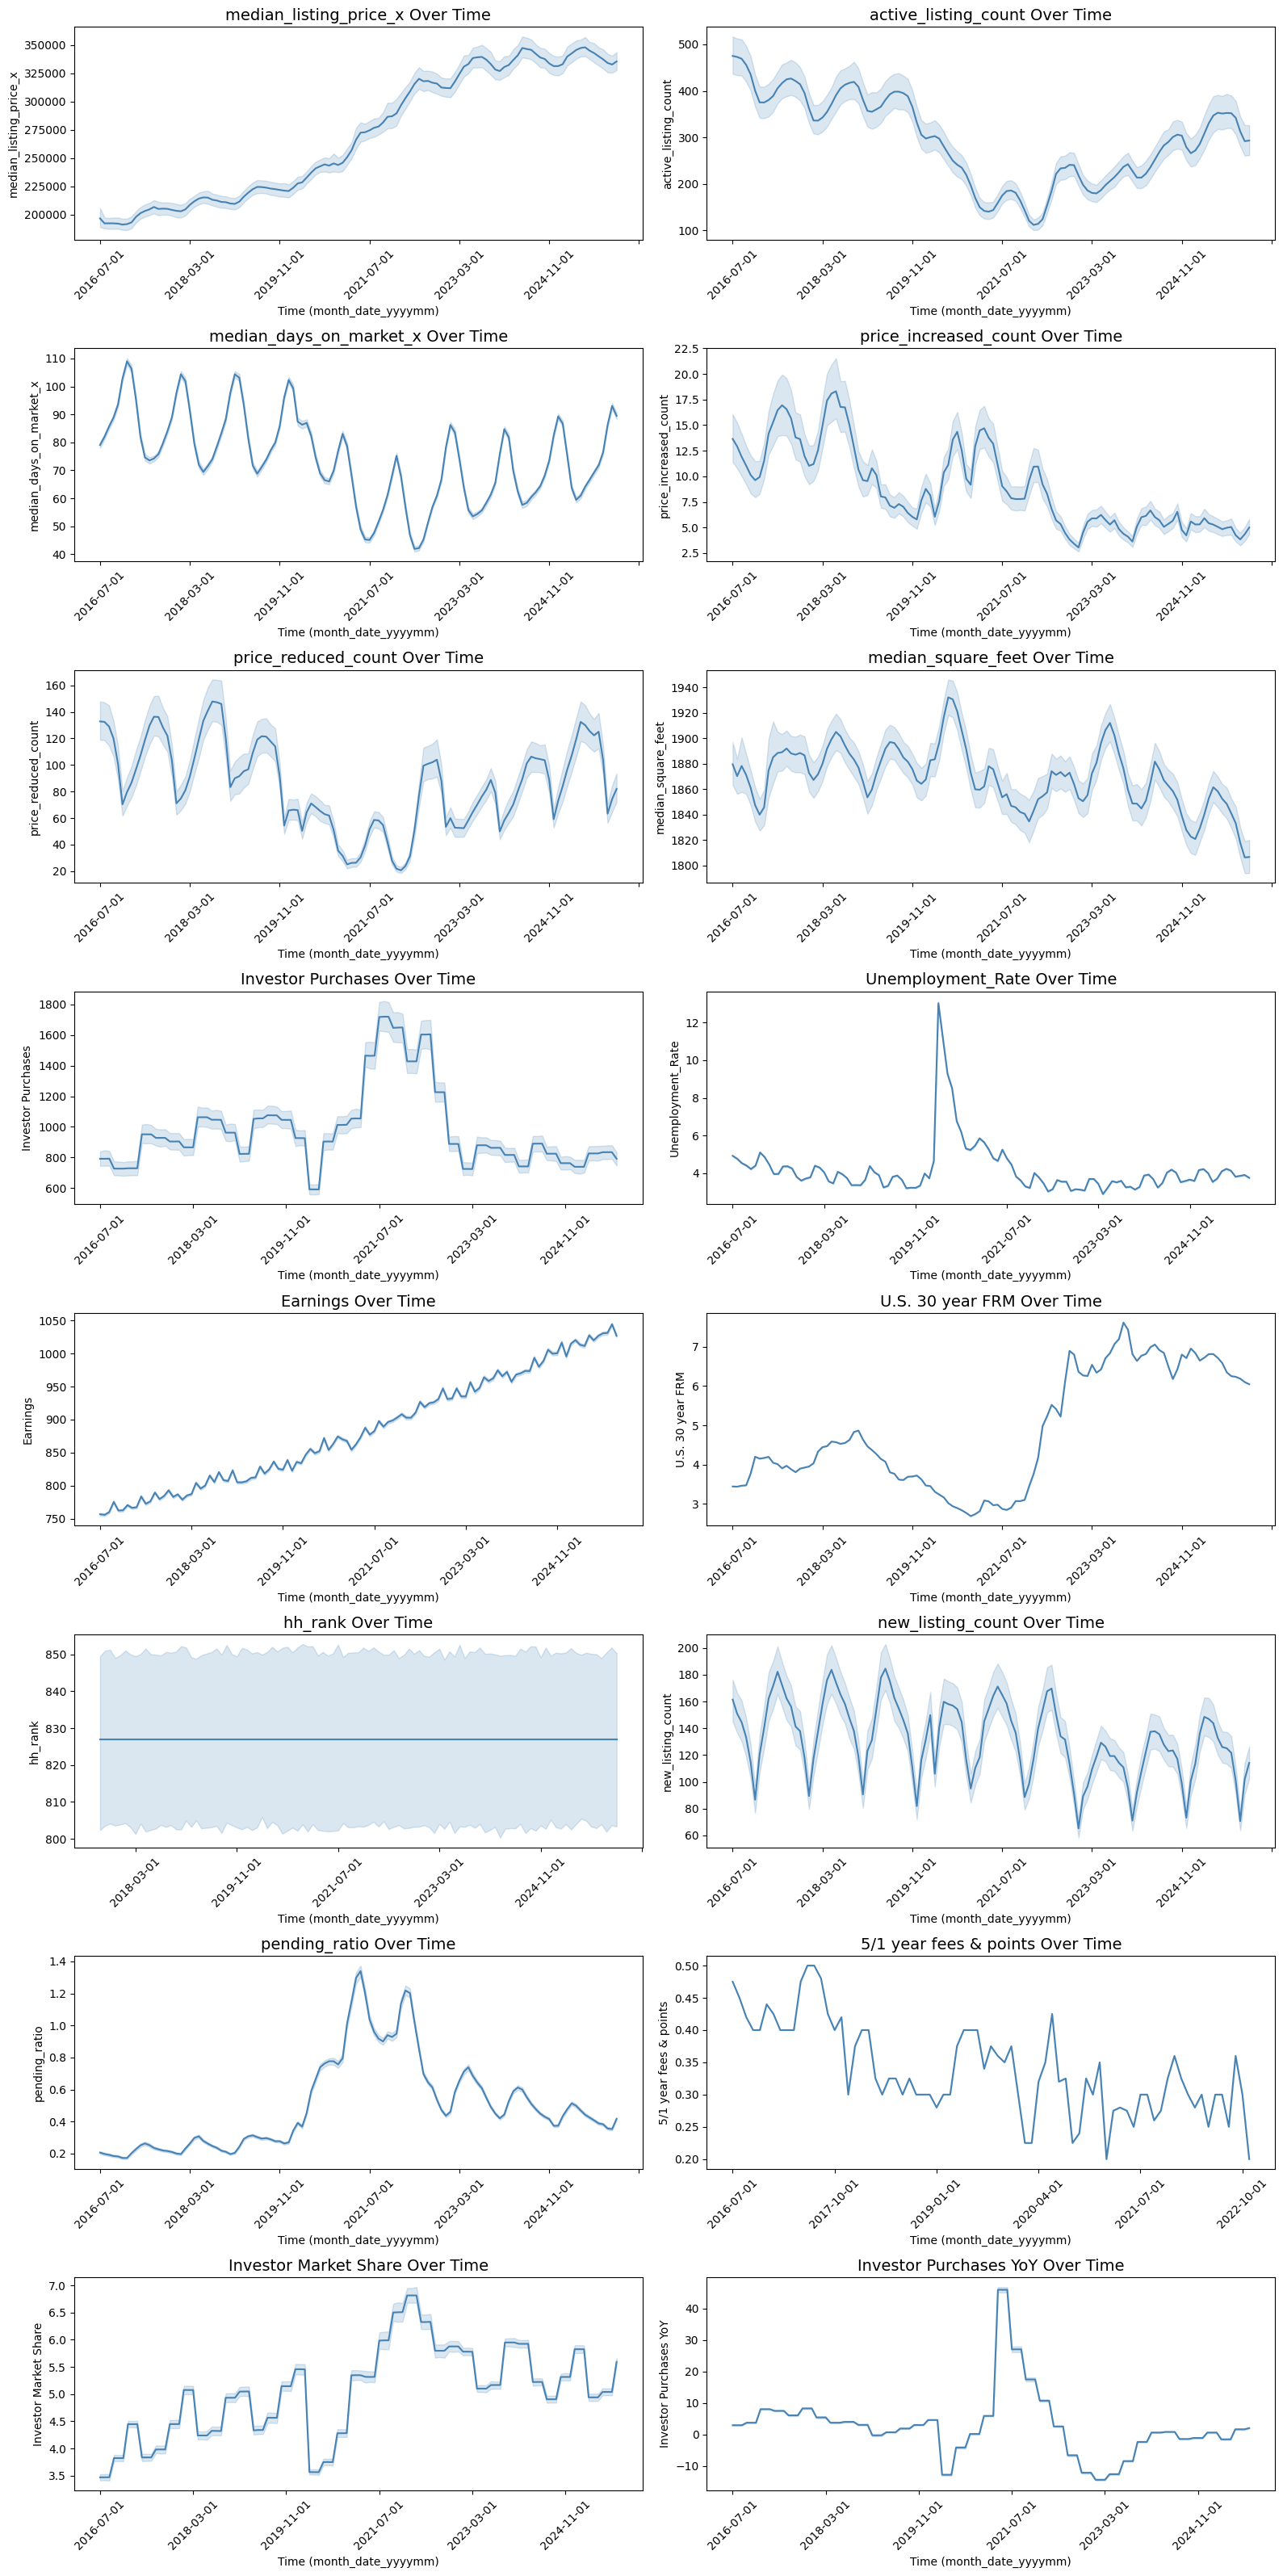

In [38]:
# Make sure the dataframe is sorted by time
df_time = df_reduced.sort_values(by='month_date_yyyymm')

# Create a 5x2 grid of subplots for the time series
fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(16, 32))
axes = axes.flatten()

for i, col in enumerate(columns_to_plot):
    if col in df_time.columns:
        # Plot the feature across time
        sns.lineplot(data=df_time, x='month_date_yyyymm', y=col, ax=axes[i], color='steelblue')
        axes[i].set_title(f'{col} Over Time', fontsize=14)
        axes[i].set_xlabel('Time (month_date_yyyymm)')
        axes[i].set_ylabel(col)
        
        # make the x-ticks legible
        axes[i].xaxis.set_major_locator(plt.MaxNLocator(7)) 
        axes[i].tick_params(axis='x', rotation=45)
    else:
        axes[i].set_visible(False)

plt.tight_layout()
plt.show()


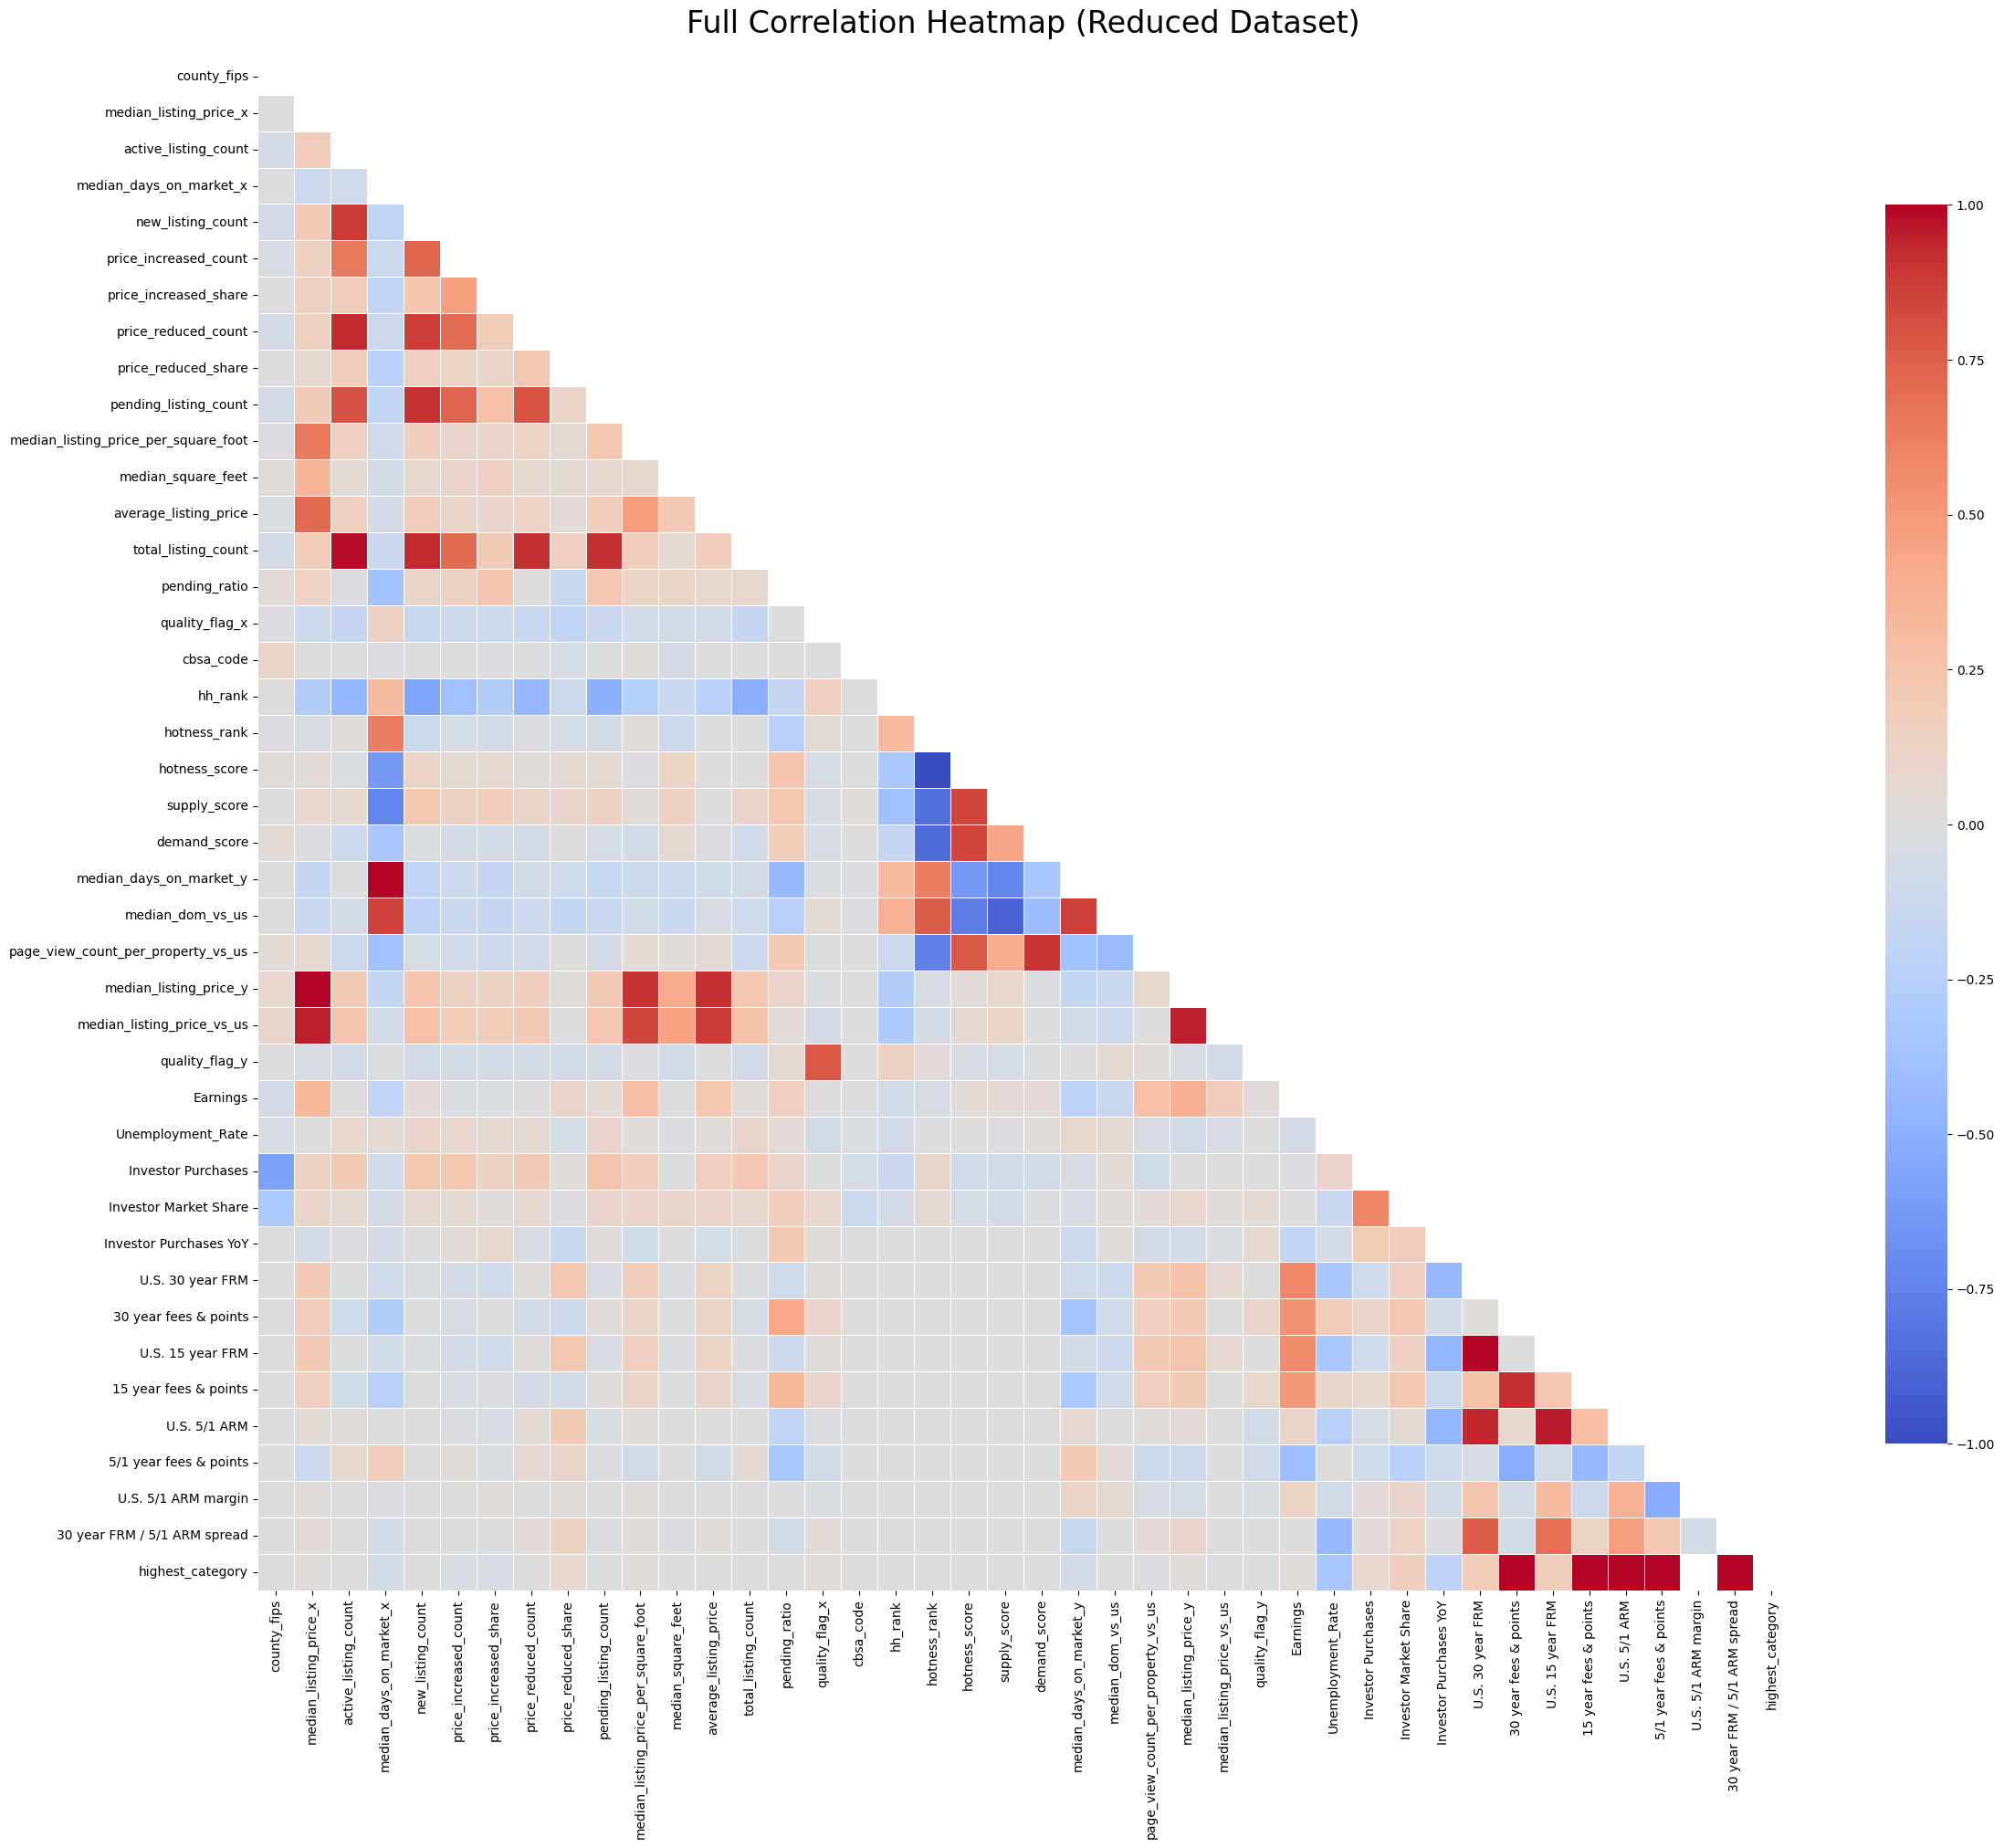

In [ ]:
# Set an extra-large figure size to accommodate the entire dataset
plt.figure(figsize=(24, 20))

# Select only the columns that contain numbers (ignoring strings/dates)
df_numeric = df_reduced.select_dtypes(include=[np.number])

# Calculate the correlation matrix for all numeric features
corr_matrix_full = df_numeric.corr()

# Create a mask to hide the duplicate upper triangle
mask_full = np.triu(np.ones_like(corr_matrix_full, dtype=bool))

# Plot the heatmap
sns.heatmap(corr_matrix_full, mask=mask_full, cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Full Correlation Heatmap (Reduced Dataset)', fontsize=24, pad=20)

plt.tight_layout()
plt.show()


In [25]:
# Unstack the correlation matrix into a simple list of pairs
corr_pairs = corr_matrix_full.unstack()

# Filter for anything with an absolute correlation greater than 0.80 
# but less than 1.0 (to exclude a variable matching itself)
highly_correlated = corr_pairs[(abs(corr_pairs) > 0.8) & (corr_pairs != 1.0)]

# Sort them from strongest absolute correlation to weakest
# (using key=abs ensures -0.92 is ranked higher than +0.85)
highly_correlated = highly_correlated.sort_values(key=abs, ascending=False)

print("These pairs are highly correlated (either positively or negatively) and could cause multicollinearity:")
print(highly_correlated.drop_duplicates().head(35))



These pairs are highly correlated (either positively or negatively) and could cause multicollinearity:
U.S. 5/1 ARM                          highest_category                        1.000000
highest_category                      30 year fees & points                   1.000000
                                      15 year fees & points                   1.000000
                                      30 year FRM / 5/1 ARM spread            1.000000
median_listing_price_y                median_listing_price_x                  1.000000
median_days_on_market_y               median_days_on_market_x                 0.999946
U.S. 30 year FRM                      U.S. 15 year FRM                        0.997655
hotness_score                         hotness_rank                           -0.995642
total_listing_count                   active_listing_count                    0.976645
U.S. 5/1 ARM                          U.S. 15 year FRM                        0.960400
median_listing_price_vs_us 

In [28]:
# Select only the columns that contain numbers (ignoring strings/dates) from full df
df_numeric_all = df.select_dtypes(include=[np.number])

# Calculate the correlation matrix for all numeric features
corr_matrix_all = df_numeric_all.corr()

# Unstack the correlation matrix into a simple list of pairs
corr_pairs_all = corr_matrix_all.unstack()

# Filter for anything with an absolute correlation greater than 0.80 
# but less than 1.0 (to exclude a variable matching itself)
highly_correlated_all = corr_pairs_all[(abs(corr_pairs_all) > 0.8) & (corr_pairs_all != 1.0)]

# Sort them from strongest absolute correlation to weakest
# (using key=abs ensures -0.92 is ranked higher than +0.85)
highly_correlated_all = highly_correlated_all.sort_values(key=abs, ascending=False)

print("These pairs are highly correlated (either positively or negatively) and could cause multicollinearity:")
print(highly_correlated_all.drop_duplicates().head(40))

These pairs are highly correlated (either positively or negatively) and could cause multicollinearity:
U.S. 5/1 ARM                             highest_category                        1.000000
highest_category                         30 year fees & points                   1.000000
15 year fees & points                    highest_category                        1.000000
30 year FRM / 5/1 ARM spread             highest_category                        1.000000
median_listing_price_x                   median_listing_price_y                  1.000000
median_days_on_market_yy_y               median_days_on_market_yy_x              1.000000
median_days_on_market_mm_x               median_days_on_market_mm_y              1.000000
median_listing_price_yy_y                median_listing_price_yy_x               1.000000
median_listing_price_mm_x                median_listing_price_mm_y               1.000000
median_days_on_market_y                  median_days_on_market_x                 0.9999

In [40]:
target_col = 'median_listing_price_x'
multicollinearity_threshold = 0.80  # Features correlated more than 80% to each other get dropped

# Get the correlation of all numeric features against the target variable
# use drop() so the target doesn't just match itself with a perfect 1.0
target_corr = corr_matrix_all[target_col].drop(target_col)

# Sort features by how strongly they correlate with the target (absolute value)
# This ensures we evaluate the most predictive, highest-value features first.
sorted_features = target_corr.abs().sort_values(ascending=False).index.tolist()

selected_features = []
dropped_features = []

# Loop down the ranked list of features
for feature in sorted_features:
    # keep the best predictor
    if not selected_features:
        selected_features.append(feature)
        continue
        
    # Check the correlation between this feature and all selected features
    is_redundant = False
    for selected in selected_features:
        # Check absolute correlation from the full matrix
        correlation = abs(corr_matrix_all.loc[feature, selected])
        
        # If it correlates too strongly with a feature we already kept, flag it to be dropped
        if correlation > multicollinearity_threshold:
            is_redundant = True
            dropped_features.append((feature, f"Correlated {correlation:.2f} with '{selected}'"))
            break
            
    # If the feature isn't redundant, add it to final list
    if not is_redundant:
        selected_features.append(feature)

# Print the final results
print(f"Started with {len(sorted_features)} features.")
print(f"Selected {len(selected_features)} non-redundant predictive features.")
print(f"Dropped {len(dropped_features)} redundant features.\n")

print("--- TOP 20 SELECTED FEATURES ---")
print("(Feature: correlation to median_listing_price_x)")
for f in selected_features[:20]: # Print top 10
    print(f"- {f}: {target_corr[f]:.2f}")
    
print("\n--- A FEW DROPPED FEATURES & WHY ---")
for f, reason in dropped_features[:5]: # Print first 5 dropped
    print(f"- {f}: {reason}")
    

# To actually create your final mathematical dataset:
# final_modeling_df = df_reduced[['month_date_yyyymm', target_col] + selected_features]


Started with 79 features.
Selected 53 non-redundant predictive features.
Dropped 26 redundant features.

--- TOP 20 SELECTED FEATURES ---
(Feature: correlation to median_listing_price_x)
- median_listing_price_y: 1.00
- median_square_feet: 0.35
- Earnings: 0.34
- hh_rank: -0.28
- page_view_count_per_property_yy: -0.21
- new_listing_count: 0.21
- U.S. 30 year FRM: 0.20
- median_listing_price_yy_x: 0.19
- median_days_on_market_y: -0.16
- 30 year fees & points: 0.16
- price_increased_share: 0.15
- Investor Purchases: 0.14
- price_increased_count: 0.14
- pending_ratio: 0.13
- quality_flag_x: -0.11
- 5/1 year fees & points: -0.11
- median_days_on_market_yy_y: 0.11
- Investor Market Share: 0.11
- price_reduced_count_yy: 0.09
- supply_score: 0.08

--- A FEW DROPPED FEATURES & WHY ---
- median_listing_price_vs_us: Correlated 0.95 with 'median_listing_price_y'
- average_listing_price: Correlated 0.92 with 'median_listing_price_y'
- median_listing_price_per_square_foot: Correlated 0.90 with 'med